# F4 · Análisis del comportamiento legislativo mediante B-Call

## Objetivo
Estimar la posición relativa y la variabilidad del comportamiento de voto de los diputados del corpus mediante B-Call, y contrastar los grupos obtenidos con una clasificación ideológica externa basada en afiliaciones partidarias.

El análisis comprende tres representaciones:
1. **B-Call automático:** los grupos se obtienen a partir de los votos.
2. **Contraste gráfico externo:** se conservan los puntajes automáticos y se representan con la clasificación externa.
3. **B-Call con grupos externos:** la clasificación partidaria define los grupos de referencia y se calculan sus puntajes.

Las etiquetas **Izquierda (L)** y **Derecha (R)** se muestran en rojo y azul, respectivamente. El pivote orienta el eje; los resultados se interpretan dentro del corpus analizado.

## Entradas y organización
Se utilizan la matriz ternaria, las afiliaciones por diputado y votación, la configuración de análisis y el catálogo de clasificación ideológica. Los cálculos se ejecutan mediante `ModeloBCall`, definido en `F4/src/analisis/bcall.py`. Las tablas, los gráficos y el registro de ejecución se exportan a `F4/data/results/bcall`.


In [ ]:
from pathlib import Path
import sys
import json
import tomllib
import hashlib
import platform
import subprocess
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

raiz = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'F4/src/analisis/bcall.py').is_file()), None)
if raiz is None:
    raise FileNotFoundError('Guarda el notebook dentro del repositorio.')
sys.path.insert(0, str(raiz / 'F4/src'))
from analisis.bcall import ModeloBCall
from analisis.orientacion import elegir_pivote, cotejar_asignacion

rutas = {
    'matriz': raiz / 'F4/data/processed/matriz_ternaria.csv',
    'afiliaciones': raiz / 'F4/data/processed/afiliacion_por_votacion.csv',
    'config': raiz / 'F4/config/analisis.toml',
    'referencia': raiz / 'F4/docs/clasificacion_ideologica_partidos_chilenos.json',
    # Solo para nombres de diputados y textos de votaciones en tablas descriptivas.
    'votos': raiz / 'F4/data/processed/votos_codificados.csv',
}
for nombre, ruta in rutas.items():
    if not ruta.is_file() or ruta.stat().st_size == 0:
        raise FileNotFoundError(f'Entrada ausente o vacía: {ruta}')
with rutas['config'].open('rb') as f:
    config = tomllib.load(f)
with rutas['referencia'].open(encoding='utf-8') as f:
    referencia = json.load(f)
print('Repositorio:', raiz)


# Etiquetas y colores de presentación; las claves internas siguen siendo L/R.
etiquetas_grupos = {'L': 'Izquierda (L)', 'R': 'Derecha (R)',
                    'Sin grupo externo': 'Independientes',
                    'L/R distintos en el período': 'Izquierda/Derecha distintas en el período'}


## 1. Carga y validación de datos
La unidad de la matriz es diputado × votación. La codificación es **+1 = Sí**, **−1 = No**, **0 = Abstención** y **NaN = sin decisión sustantiva registrada**. Los faltantes no se imputan.

La afiliación corresponde a la fecha de cada votación. Se verifican la unicidad de los identificadores, la clave diputado × votación, los valores permitidos y la correspondencia exacta entre decisiones observadas y registros de afiliación. Esta información no constituye un padrón de asistencia.

La clasificación binaria se toma sin modificaciones del `codigo_binario` del JSON de referencia. En ese catálogo, **Partido de la Gente** y **Partido Demócratas Chile** están asignados a **Derecha (R)** como casos frontera. Los registros independientes no reciben una etiqueta ideológica por su sola condición de independencia.


In [46]:
matriz = pd.read_csv(rutas['matriz'], index_col='diputado_id')
matriz.index = pd.Index(pd.to_numeric(matriz.index, errors='raise').astype('int64'), name='diputado_id')
matriz.columns = pd.Index(pd.to_numeric(matriz.columns, errors='raise').astype('int64'), name='votacion_id')
afiliaciones = pd.read_csv(rutas['afiliaciones'], dtype={'partido_id': 'string'})
requeridas = {'diputado_id', 'votacion_id', 'fecha', 'partido_nombre'}
if not requeridas.issubset(afiliaciones.columns):
    raise ValueError(f'Faltan columnas: {requeridas - set(afiliaciones.columns)}')
for columna in ['diputado_id', 'votacion_id']:
    valores = pd.to_numeric(afiliaciones[columna], errors='raise')
    if valores.isna().any() or (valores % 1 != 0).any():
        raise ValueError(f'Identificador inválido: {columna}')
    afiliaciones[columna] = valores.astype('int64')
if afiliaciones.duplicated(['diputado_id', 'votacion_id']).any():
    raise ValueError('Afiliaciones duplicadas por diputado × votación.')
if not afiliaciones.diputado_id.isin(matriz.index).all() or not afiliaciones.votacion_id.isin(matriz.columns).all():
    raise ValueError('Las afiliaciones contienen IDs fuera del universo de la matriz.')
ModeloBCall._validar_matriz(matriz)
perfil = pd.Series({
    'diputados': len(matriz), 'votaciones': matriz.shape[1],
    'decisiones_observadas': int(matriz.notna().sum().sum()),
    'celdas_sin_decision': int(matriz.isna().sum().sum()),
    'filas_afiliacion': len(afiliaciones),
})
display(perfil.to_frame('conteo'))
display(matriz.head())

# La afiliación debe cubrir exactamente las decisiones observadas en la matriz.
# Evita declarar consistente a alguien cuya afiliación falta en parte del corpus.
observadas = matriz.notna().stack()
pares_observados = observadas.index[observadas.to_numpy()]
pares_afiliacion = pd.MultiIndex.from_frame(
    afiliaciones[['diputado_id', 'votacion_id']]
)
faltan_afiliaciones = pares_observados.difference(pares_afiliacion)
sobran_afiliaciones = pares_afiliacion.difference(pares_observados)
if len(faltan_afiliaciones) or len(sobran_afiliaciones):
    raise ValueError(
        f'Afiliación y matriz no coinciden: {len(faltan_afiliaciones)} '
        f'decisiones sin afiliación y {len(sobran_afiliaciones)} afiliaciones sin decisión.'
    )
print('Validación de pares diputado × votación: OK')


,conteo
diputados,151
votaciones,15
decisiones_observadas,1993
celdas_sin_decision,272
filas_afiliacion,1993


votacion_id,20627,20628,20629,20630,20631,20632,20633,20634,20635,20636,20637,21217,21218,21219,42724
diputado_id,,,,,,,,,,,,,,,
74,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
803,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0
815,1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0
872,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
917,1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


Validación de pares diputado × votación: OK


## 2. Definición del pivote y parámetros
El pivote se selecciona entre diputados de UDI o Partido Republicano con afiliación partidaria observada consistente y participación estrictamente superior al 10 %. Se prioriza la mayor participación y, en caso de empate, el menor identificador. La selección debe coincidir con el valor definido en la configuración.

Se utiliza distancia Manhattan normalizada (`distance_method=1`) y umbral de participación `threshold=0.10`. El grupo del pivote define el lado positivo del eje.


In [47]:
threshold = config['bcall']['threshold']
metodo_distancia = config['bcall']['metodo_distancia']
if threshold != 0.10 or metodo_distancia != 1:
    raise ValueError('Esta ejecución requiere threshold=0.10 y distancia Manhattan=1.')
pivote = elegir_pivote(matriz, afiliaciones, referencia, threshold=threshold)
if pivote != config['orientacion']['pivot']:
    raise ValueError(f'Pivote seleccionado {pivote} difiere del configurado; revisa la decisión.')
display(afiliaciones.loc[afiliaciones.diputado_id.eq(pivote),
                        ['diputado_id', 'votacion_id', 'fecha', 'partido_nombre']])
print('Pivote:', pivote)


,diputado_id,votacion_id,fecha,partido_nombre
2,815,20627,2023-05-08 19:05:22,Unión Demócrata Independiente
124,815,20628,2023-05-08 19:06:49,Unión Demócrata Independiente
252,815,20629,2023-05-08 19:08:21,Unión Demócrata Independiente
387,815,20630,2023-05-08 19:09:23,Unión Demócrata Independiente
522,815,20631,2023-05-08 19:10:13,Unión Demócrata Independiente
657,815,20632,2023-05-08 19:11:06,Unión Demócrata Independiente
792,815,20633,2023-05-08 19:11:56,Unión Demócrata Independiente
927,815,20634,2023-05-08 19:12:58,Unión Demócrata Independiente
1062,815,20635,2023-05-08 19:13:51,Unión Demócrata Independiente
1197,815,20636,2023-05-08 19:15:04,Unión Demócrata Independiente


Pivote: 815


## 3. Estimación automática
El agrupamiento se realiza sobre la matriz completa. El filtro de participación estrictamente superior al 10 % se aplica después del agrupamiento y antes del cálculo de puntajes. Los votos se orientan y estandarizan mediante desviación muestral; el empate de medias L/R recibe orientación −1. Las votaciones sin varianza positiva no contribuyen a los puntajes.

- **d1:** posición relativa, calculada como promedio de votos orientados y estandarizados.
- **d2:** variabilidad individual entre votaciones utilizables, calculada con desviación muestral; requiere al menos dos observaciones.
- **m_i:** número de votaciones utilizables para el diputado.

`grupo_bcall` identifica los grupos efectivos del eje; R contiene al pivote final. La interpretación ideológica se circunscribe al corpus y a la orientación establecida.


In [48]:
resultado = ModeloBCall().calcular_auto(
    matriz, pivot=pivote, distance_method=metodo_distancia, threshold=threshold,
)
resumen = resultado.diputados[
    ['d1', 'd2', 'm_i', 'participacion', 'grupo_bcall', 'razon_NA_d1', 'razon_NA_d2']
].sort_values('d1')
display(resumen)
display(resultado.diputados.groupby('grupo_bcall').agg(
    diputados=('d1', 'size'), media_d1=('d1', 'mean'), mediana_d2=('d2', 'median')
))
print('Incluidos:', len(resultado.diputados))
print('Excluidos:', int((~resultado.seleccion.incluido).sum()))

# Copia para verificar que el cotejo externo no altera el resultado automático.
automatico_original = resultado.diputados.copy(deep=True)


,d1,d2,m_i,participacion,grupo_bcall,razon_NA_d1,razon_NA_d2
diputado_id,,,,,,,
1074,-0.862877,NaN,1,0.133333,L,None,MENOS_DE_DOS_VOTACIONES
991,-0.726106,0.095272,13,1.000000,L,None,NaN
1037,-0.726106,0.095272,13,0.933333,L,None,NaN
975,-0.726106,0.095272,13,1.000000,L,None,NaN
1038,-0.726106,0.095272,13,1.000000,L,None,NaN
...,...,...,...,...,...,...,...
1146,1.458364,0.163694,13,1.000000,R,None,NaN
1123,1.458364,0.163694,13,1.000000,R,None,NaN
1133,1.458364,0.163694,13,0.933333,R,None,NaN


,diputados,media_d1,mediana_d2
grupo_bcall,,,
L,94,-0.611300,0.095272
R,42,1.351877,0.320638


Incluidos: 136
Excluidos: 15


## 4. Cobertura y exclusiones
La participación observada corresponde a la proporción de columnas de la matriz con decisión sustantiva registrada. Se conservan los motivos de exclusión y las razones de no estimabilidad de d1/d2. Los valores no estimables se mantienen como faltantes.


In [49]:
display(resultado.seleccion.loc[~resultado.seleccion.incluido])
display(resultado.votaciones)
display(resultado.diputados.loc[
    resultado.diputados.d1.isna() | resultado.diputados.d2.isna(),
    ['d1', 'd2', 'm_i', 'razon_NA_d1', 'razon_NA_d2'],
])


,tiene_cluster,participacion,incluido,razon_exclusion
diputado_id,,,,
872,True,0.066667,False,PARTICIPACION_NO_SUPERA_UMBRAL
989,True,0.066667,False,PARTICIPACION_NO_SUPERA_UMBRAL
1015,True,0.066667,False,PARTICIPACION_NO_SUPERA_UMBRAL
1027,True,0.066667,False,PARTICIPACION_NO_SUPERA_UMBRAL
1039,True,0.066667,False,PARTICIPACION_NO_SUPERA_UMBRAL
1051,True,0.066667,False,PARTICIPACION_NO_SUPERA_UMBRAL
1053,True,0.066667,False,PARTICIPACION_NO_SUPERA_UMBRAL
1063,True,0.066667,False,PARTICIPACION_NO_SUPERA_UMBRAL
1069,True,0.066667,False,PARTICIPACION_NO_SUPERA_UMBRAL


,n_observados,media,desviacion,media_L,media_R,orientacion,incluida_por_varianza,orientacion_definida,razones_exclusion
votacion_id,,,,,,,,,
20627,122,1.000000,0.000000,1.000000,1.000000,-1.0,False,True,[SIN_VARIANZA_O_MENOS_DE_DOS_OBSERVACIONES]
20628,128,1.000000,0.000000,1.000000,1.000000,-1.0,False,True,[SIN_VARIANZA_O_MENOS_DE_DOS_OBSERVACIONES]
20629,135,0.355556,0.926127,0.924731,-0.904762,-1.0,True,True,[]
20630,135,0.370370,0.912114,0.903226,-0.809524,-1.0,True,True,[]
20631,135,0.355556,0.934150,0.946237,-0.952381,-1.0,True,True,[]
20632,135,0.377778,0.929345,1.000000,-1.000000,-1.0,True,True,[]
20633,135,0.407407,0.908470,1.000000,-0.904762,-1.0,True,True,[]
20634,135,0.400000,0.915864,0.978495,-0.880952,-1.0,True,True,[]
20635,135,0.385185,0.914111,0.978495,-0.928571,-1.0,True,True,[]


,d1,d2,m_i,razon_NA_d1,razon_NA_d2
diputado_id,,,,,
1074,-0.862877,NaN,1,None,MENOS_DE_DOS_VOTACIONES


## 5. Contraste con la clasificación externa histórica
La unidad de cotejo es diputado × votación, utilizando la afiliación de esa fecha. La concordancia se calcula exclusivamente entre filas con resultado automático y etiqueta externa disponibles. Los registros independientes o sin etiqueta externa quedan fuera del denominador.

Las discrepancias se conservan como diferencias entre el comportamiento estimado y la referencia partidaria. El cotejo no modifica los grupos ni los puntajes automáticos y no constituye una medida de exactitud ideológica.


In [50]:
cotejo = cotejar_asignacion(resultado.diputados.grupo_bcall, afiliaciones, referencia)
comparables = cotejo.loc[cotejo.comparable]
concordancia = float(comparables.coincide.mean()) if len(comparables) else None
display(pd.Series({
    'filas_cotejo': len(cotejo), 'filas_comparables': len(comparables),
    'filas_no_comparables': int((~cotejo.comparable).sum()),
    'proporcion_coincidencia_por_fila': concordancia,
}).to_frame('valor'))
display(pd.crosstab(comparables.grupo_externo, comparables.grupo_bcall))
display(cotejo.loc[cotejo.comparable & ~cotejo.coincide.fillna(False)])
independientes = cotejo.partido_nombre.eq('Independientes')
assert cotejo.loc[independientes, 'codigo_externo'].isna().all()

pd.testing.assert_frame_equal(resultado.diputados, automatico_original)
assert cotejo.loc[~cotejo.comparable, 'coincide'].isna().all()
assert comparables.coincide.notna().all()
print('Discrepancias conservadas:', int((~comparables.coincide).sum()))
print('Diputados con al menos una discrepancia:',
      comparables.loc[~comparables.coincide, 'diputado_id'].nunique())


,valor
filas_cotejo,1993.00000
filas_comparables,1479.00000
filas_no_comparables,514.00000
proporcion_coincidencia_por_fila,0.82691


grupo_bcall,L,R
grupo_externo,,
L,726,0
R,256,497


,diputado_id,votacion_id,fecha,partido_id,partido_nombre,partido_alias,grupo_bcall,codigo_externo,grupo_externo,comparable,coincide,razon_no_comparable
4,948,20627,2023-05-08 19:05:22,PDG,Partido de la Gente,PDG,L,1,R,True,False,None
5,953,20627,2023-05-08 19:05:22,RN,Renovación Nacional,RN,L,1,R,True,False,None
12,999,20627,2023-05-08 19:05:22,RN,Renovación Nacional,RN,L,1,R,True,False,None
20,1019,20627,2023-05-08 19:05:22,RN,Renovación Nacional,RN,L,1,R,True,False,None
21,1021,20627,2023-05-08 19:05:22,RN,Renovación Nacional,RN,L,1,R,True,False,None
...,...,...,...,...,...,...,...,...,...,...,...,...
1939,1119,42724,2024-08-26 19:03:25,PSC,Partido Social Cristiano,PSC,L,1,R,True,False,None
1950,1132,42724,2024-08-26 19:03:25,EVOP,Evolución Política,EVOP,L,1,R,True,False,None
1964,1149,42724,2024-08-26 19:03:25,RN,Renovación Nacional,RN,L,1,R,True,False,None
1974,1163,42724,2024-08-26 19:03:25,RN,Renovación Nacional,RN,L,1,R,True,False,None


Discrepancias conservadas: 256
Diputados con al menos una discrepancia: 21


## 6. Visualización de resultados individuales
El plano d1/d2 representa posición relativa y variabilidad. Solo se muestran diputados con ambos puntajes estimables; los demás permanecen en las tablas con sus razones de no estimabilidad.

Muchos diputados comparten exactamente la misma coordenada, por lo que un punto por diputado ocultaría la mayor parte de cada bloque. Para evitar ese sobretrazado, los tres gráficos de esta sección usan la misma codificación:

- **Burbujas por coordenada exacta:** una marca por posición y grupo, con área proporcional al número de diputados. No se aplica jitter ni redondeo.
- **Conteos:** las posiciones compartidas se rotulan con `×n`. Si en una misma posición coinciden grupos distintos, el rótulo los desglosa.
- **Distribuciones marginales:** densidad kernel de d1 (arriba) y d2 (derecha) por grupo, que muestra la concentración de cada bloque.
- **Forma y color:** círculo rojo = Izquierda (L) y cuadrado azul = Derecha (R), lo que permite leerlos también en blanco y negro. El pivote se identifica con una estrella negra dibujada encima de todo.
- **Subtítulo:** indica el total de diputados y de posiciones distintas, para hacer visible la concentración.

In [51]:
# Gráfico común del plano d1/d2: burbujas por coordenada exacta, conteos y marginales.
from matplotlib.lines import Line2D

# Rojo/azul validados para daltonismo; el gris es oscuro para separarse del azul.
# La forma del marcador duplica la codificación del color (impresión en B/N).
ESTILO_GRUPOS = {
    'L': {'color': '#E74C3C', 'marker': 'o', 'corto': 'L'},
    'R': {'color': '#3498DB', 'marker': 's', 'corto': 'R'},
    'Sin grupo externo': {'color': '#5E5E5E', 'marker': 'X', 'corto': 'Ind.'},
    'L/R distintos en el período': {'color': '#7B3294', 'marker': 'D', 'corto': 'L/R'},
}
AREA_POR_DIPUTADO = 36  # puntos² por diputado; el área es proporcional al conteo
MINIMO_ROTULO = 2       # se rotulan posiciones compartidas por al menos 2 diputados
MINIMO_MARGINAL = 5     # menos diputados no sostienen una densidad kernel
# Ancho de banda fijo (fracción del eje), igual para todos los grupos: con coordenadas
# repetidas, un ancho proporcional a la dispersión produce picos que aplastan al resto.
BANDA_MARGINAL = 0.035
TINTA, TINTA_SECUNDARIA = '#333333', '#666666'


def _densidad(valores, malla, banda):
    """KDE gaussiana con ancho de banda fijo; integra 1 dentro de cada grupo."""
    z = (malla[:, None] - np.asarray(valores, dtype=float)[None, :]) / banda
    return np.exp(-0.5 * z ** 2).mean(axis=1) / (banda * np.sqrt(2 * np.pi))


def _rotular_conteos(ax, rotulos):
    """Coloca cada conteo junto al borde de su burbuja y evita superponer rótulos."""
    escala = ax.figure.dpi / 72
    borde_derecho = ax.get_window_extent().x1
    colocados = []  # (centro x, base y, ancho) de cada rótulo, en píxeles
    for x, y, texto, radio in sorted(rotulos, key=lambda r: (r[1], r[0])):
        px, py = ax.transData.transform((x, y))
        separacion = radio * 0.72 + 2
        ancho, alto = 5.2 * len(texto), 10.5
        # A la derecha de la burbuja salvo que el texto se salga del eje.
        a_la_derecha = px + (separacion + ancho) * escala <= borde_derecho
        dx = separacion if a_la_derecha else -separacion
        centro = px + (dx + (ancho / 2 if a_la_derecha else -ancho / 2)) * escala
        dy = separacion
        while any(abs(centro - cx) < (ancho + cw) / 2 * escala
                  and abs(py + dy * escala - cy) < alto * escala
                  for cx, cy, cw in colocados):
            dy += alto
        colocados.append((centro, py + dy * escala, ancho))
        desplazado = dy > separacion
        ax.annotate(
            texto, (x, y), xytext=(dx, dy), textcoords='offset points', fontsize=8.5,
            color=TINTA, ha='left' if a_la_derecha else 'right', va='bottom', zorder=12,
            arrowprops={'arrowstyle': '-', 'color': '#999999', 'lw': 0.6} if desplazado else None,
        )


def graficar_plano_bcall(diputados, columna_grupo, pivote, titulo, nombre_leyenda,
                         limites=None):
    """Dibuja d1/d2 sin jitter ni redondeo: una burbuja por coordenada exacta y grupo.

    Devuelve (figura, eje principal). El conteo total y las posiciones distintas
    van en el subtítulo para que la concentración sea visible.
    """
    puntos = diputados.dropna(subset=['d1', 'd2']).copy()
    puntos['grupo'] = puntos[columna_grupo].astype('object')
    grupos = [g for g in ESTILO_GRUPOS if puntos.grupo.eq(g).any()]
    agregados = (puntos.groupby(['grupo', 'd1', 'd2'], as_index=False).size()
                 .rename(columns={'size': 'n'}))
    assert int(agregados.n.sum()) == len(puntos)

    fig = plt.figure(figsize=(11.5, 7))
    rejilla = fig.add_gridspec(2, 3, width_ratios=(6, 1.1, 2.6), height_ratios=(1.1, 5),
                               wspace=0.04, hspace=0.04,
                               left=0.06, right=0.99, top=0.88, bottom=0.12)
    ax = fig.add_subplot(rejilla[1, 0])
    ax_x = fig.add_subplot(rejilla[0, 0], sharex=ax)
    ax_y = fig.add_subplot(rejilla[1, 1], sharey=ax)

    # Burbujas grandes primero para que las pequeñas queden visibles encima.
    for _, fila in agregados.sort_values('n', ascending=False).iterrows():
        estilo = ESTILO_GRUPOS[fila.grupo]
        ax.scatter(fila.d1, fila.d2, s=AREA_POR_DIPUTADO * fila.n, color=estilo['color'],
                   marker=estilo['marker'], alpha=0.6, edgecolors='white', linewidths=1.0,
                   zorder=3)

    ax.axvline(0, color='#999999', linewidth=0.8, linestyle='--', zorder=1)
    ax.grid(True, color='#E5E5E5', linewidth=0.6, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel('d1 · Posición relativa', color=TINTA)
    ax.set_ylabel('d2 · Variabilidad', color=TINTA)
    if limites is None:
        rango_x = puntos.d1.max() - puntos.d1.min()
        rango_y = puntos.d2.max() - puntos.d2.min()
        limites = ((puntos.d1.min() - 0.08 * rango_x, puntos.d1.max() + 0.12 * rango_x),
                   (puntos.d2.min() - 0.08 * rango_y, puntos.d2.max() + 0.12 * rango_y))
    ax.set_xlim(limites[0])
    ax.set_ylim(limites[1])

    # Marginales: una densidad por grupo con el mismo ancho de banda para todos.
    malla_x = np.linspace(*limites[0], 400)
    malla_y = np.linspace(*limites[1], 400)
    banda_x = BANDA_MARGINAL * (limites[0][1] - limites[0][0])
    banda_y = BANDA_MARGINAL * (limites[1][1] - limites[1][0])
    for grupo in grupos:
        datos = puntos.loc[puntos.grupo.eq(grupo)]
        if len(datos) < MINIMO_MARGINAL:
            continue
        color = ESTILO_GRUPOS[grupo]['color']
        densidad_x = _densidad(datos.d1, malla_x, banda_x)
        densidad_y = _densidad(datos.d2, malla_y, banda_y)
        ax_x.fill_between(malla_x, densidad_x, color=color, alpha=0.3, linewidth=0)
        ax_x.plot(malla_x, densidad_x, color=color, linewidth=1.2)
        ax_y.fill_betweenx(malla_y, densidad_y, color=color, alpha=0.3, linewidth=0)
        ax_y.plot(densidad_y, malla_y, color=color, linewidth=1.2)
    ax_x.set_ylim(bottom=0)
    ax_y.set_xlim(left=0)
    for marginal in (ax_x, ax_y):
        marginal.set_axis_off()

    # Un rótulo por coordenada; si comparten posición varios grupos se desglosa.
    rotulos = []
    for (d1, d2), filas in agregados.groupby(['d1', 'd2']):
        total = int(filas.n.sum())
        if total < MINIMO_ROTULO:
            continue
        texto = f'×{total}'
        if len(filas) > 1:
            texto += ' (' + ' · '.join(
                f"{int(f.n)} {ESTILO_GRUPOS[f.grupo]['corto']}" for f in filas.itertuples()
            ) + ')'
        rotulos.append((d1, d2, texto, (AREA_POR_DIPUTADO * filas.n.max()) ** 0.5 / 2))
    _rotular_conteos(ax, rotulos)

    # El pivote va encima de todo, con borde blanco para separarlo de su burbuja.
    p = diputados.loc[pivote]
    pivote_visible = pd.notna(p.d1) and pd.notna(p.d2)
    if pivote_visible:
        ax.scatter([p.d1], [p.d2], marker='*', s=350, color='black', edgecolors='white',
                   linewidths=1.5, zorder=10)

    n_grupo = puntos.grupo.value_counts()
    manejadores = []
    for g in grupos:
        etiqueta = f"{etiquetas_grupos.get(g, g)} (n={n_grupo[g]})"
        if g not in ('L', 'R'):
            etiqueta += f" · {ESTILO_GRUPOS[g]['corto']}"
        manejadores.append(Line2D(
            [], [], linestyle='', marker=ESTILO_GRUPOS[g]['marker'], markersize=9,
            markerfacecolor=ESTILO_GRUPOS[g]['color'], markeredgecolor='white', alpha=0.8,
            label=etiqueta,
        ))
    if pivote_visible:
        manejadores.append(Line2D([], [], linestyle='', marker='*', markersize=14,
                                  markerfacecolor='black', markeredgecolor='white',
                                  label=f'Pivote {pivote}'))
    ax_leyenda = fig.add_subplot(rejilla[:, 2])
    ax_leyenda.set_axis_off()
    leyenda = ax_leyenda.legend(handles=manejadores, title=nombre_leyenda, loc='upper left',
                                frameon=False, fontsize=9, title_fontsize=9.5,
                                alignment='left')
    ax_leyenda.add_artist(leyenda)
    maximo = int(agregados.n.max())
    referencias = (1, 10, 50) if maximo >= 40 else (1, 5, 10)
    tamanos = [ax_leyenda.scatter([], [], s=AREA_POR_DIPUTADO * c, facecolors='none',
                                  edgecolors='#666666',
                                  label=f"{c} diputado{'s' if c != 1 else ''}")
               for c in referencias]
    ax_leyenda.legend(handles=tamanos, title='Área = diputados\nen la misma posición',
                      loc='upper left', bbox_to_anchor=(0, 0.52), frameon=False,
                      fontsize=9, title_fontsize=9.5, labelspacing=2.6, borderpad=1.4,
                      handletextpad=2.2,
                      alignment='left')

    fig.text(0.06, 0.975, titulo, fontsize=13, fontweight='bold', color=TINTA, va='top')
    fig.text(0.06, 0.935,
             f'{len(puntos)} diputados con d1 y d2 estimables · '
             f'{agregados[["d1", "d2"]].drop_duplicates().shape[0]} posiciones distintas',
             fontsize=10, color=TINTA_SECUNDARIA, va='top')
    fig.text(0.06, 0.02,
             'Coordenadas originales, sin jitter ni redondeo. Se rotulan las posiciones con '
             f'{MINIMO_ROTULO} o más diputados. Marginales: densidad kernel por grupo con ancho '
             f'de banda fijo ({BANDA_MARGINAL:.1%} del eje), solo grupos con {MINIMO_MARGINAL} '
             'o más diputados.',
             fontsize=8.5, color=TINTA_SECUNDARIA, va='bottom', wrap=True)
    return fig, ax


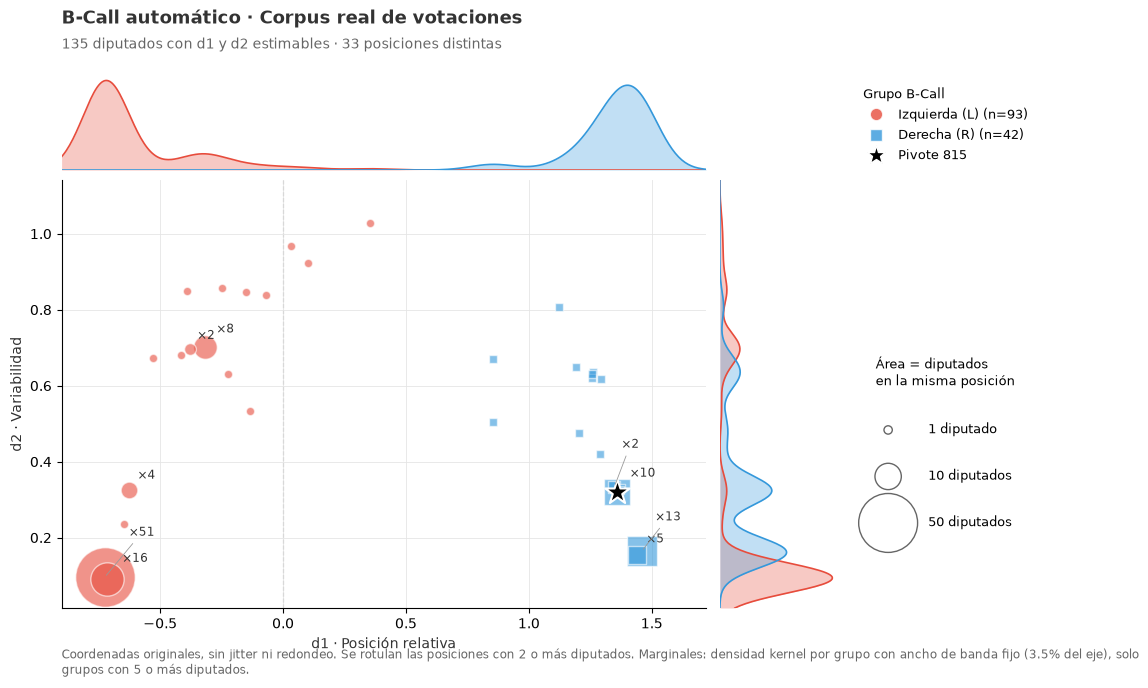

In [52]:
fig, ax = graficar_plano_bcall(
    resultado.diputados, 'grupo_bcall', pivote,
    titulo='B-Call automático · Corpus real de votaciones',
    nombre_leyenda='Grupo B-Call',
)
plt.show()

### 6.1. Puntajes automáticos según clasificación externa
Se conservan las coordenadas y escalas del análisis automático. La etiqueta gráfica resume la clasificación externa observada: una única etiqueta L/R, ausencia de etiqueta o etiquetas L/R distintas en el período. Las discrepancias no se eliminan.

Se usa la codificación de la sección 6: **círculo rojo = izquierda**, **cuadrado azul = derecha**, **cruz gris = independientes** (diputados sin grupo externo) y **rombo violeta = etiquetas externas distintas**. Cuando en una misma coordenada coinciden grupos externos distintos, el rótulo desglosa cuántos diputados hay de cada uno.

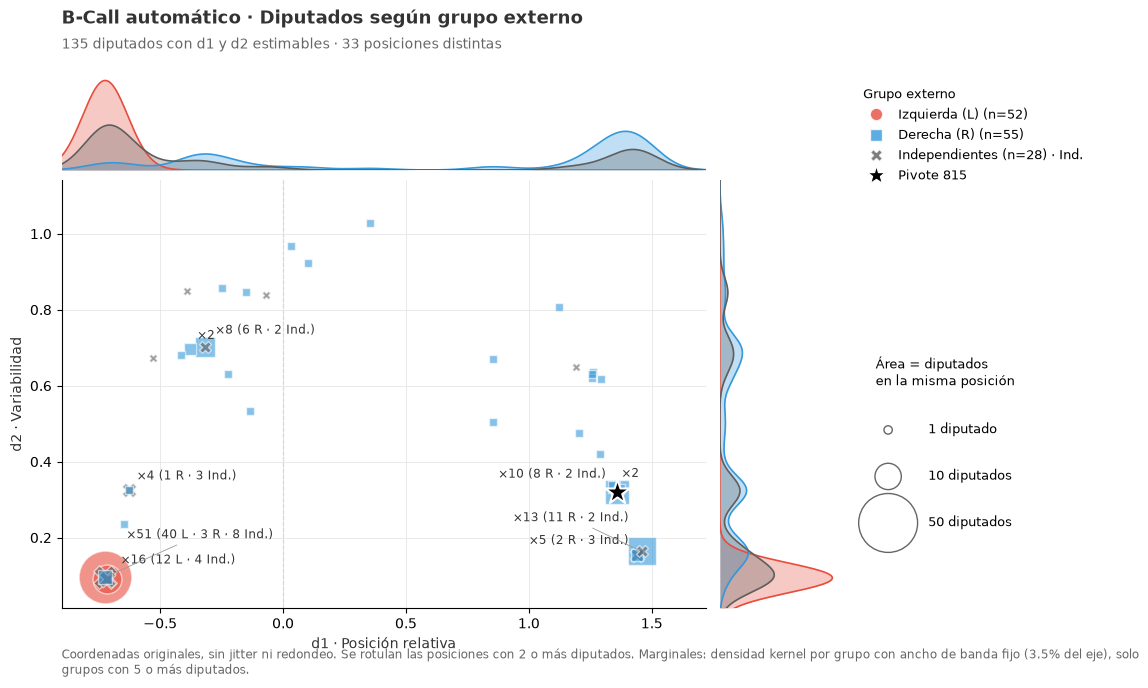

,d1,d2,grupo_externo,n_diputados
0,-0.726106,0.095272,L,40
1,-0.714709,0.089775,L,12
2,-0.726106,0.095272,R,3
3,-0.627907,0.324555,R,1
4,-0.317352,0.702703,R,6
5,1.360165,0.320638,R,8
6,1.439037,0.154706,R,2
7,1.458364,0.163694,R,11
8,-0.726106,0.095272,Sin grupo externo,8
9,-0.714709,0.089775,Sin grupo externo,4


In [53]:
# Conservar coordenadas B-Call y colorear por referencia externa histórica.
def resumir_grupo_externo(serie):
    grupos = set(serie.dropna())
    if len(grupos) == 1:
        return next(iter(grupos))
    if len(grupos) == 0:
        return "Sin grupo externo"
    return "L/R distintos en el período"

grupo_externo = cotejo.groupby("diputado_id")["grupo_externo"].agg(
    resumir_grupo_externo
)
puntos_externos = resultado.diputados.join(
    grupo_externo.rename("grupo_externo")
)
puntos_externos["grupo_externo"] = puntos_externos["grupo_externo"].fillna(
    "Sin grupo externo"
)
# En el gráfico este grupo se rotula "Independientes": verificar que lo sean.
sin_grupo = puntos_externos.index[puntos_externos.grupo_externo.eq("Sin grupo externo")]
partidos_sin_grupo = set(cotejo.loc[cotejo.diputado_id.isin(sin_grupo), "partido_nombre"])
if partidos_sin_grupo - {"Independientes"}:
    raise ValueError(f"Hay diputados sin grupo externo que no son independientes: "
                     f"{sorted(partidos_sin_grupo - {'Independientes'})}")
visibles_externos = puntos_externos.dropna(subset=["d1", "d2"])
superposiciones_externas = visibles_externos.groupby(
    ["grupo_externo", "d1", "d2"], as_index=False
).size().rename(columns={"size": "n_diputados"})
assert int(superposiciones_externas.n_diputados.sum()) == len(visibles_externos)

# Mismas escalas que el gráfico automático para comparar directamente.
fig_externo, ax_externo = graficar_plano_bcall(
    puntos_externos, "grupo_externo", pivote,
    titulo="B-Call automático · Diputados según grupo externo",
    nombre_leyenda="Grupo externo",
    limites=(ax.get_xlim(), ax.get_ylim()),
)
plt.show()

# Diagnóstico de posiciones compartidas entre diferentes grupos externos.
coordenadas_mixtas = superposiciones_externas.groupby(["d1", "d2"]).grupo_externo.nunique()
coordenadas_mixtas = coordenadas_mixtas.loc[coordenadas_mixtas.gt(1)].index
mezclas = superposiciones_externas.set_index(["d1", "d2"]).loc[
    lambda tabla: tabla.index.isin(coordenadas_mixtas)
].reset_index()
display(mezclas)

## 7. Estimación con grupos externos
La afiliación partidaria observada define una etiqueta L/R por diputado, suministrada a `ModeloBCall.calcular()` mediante el argumento `clustering`. Esta clasificación interviene en las medias de grupo y en la orientación; los puntajes se calculan para el universo elegible de este escenario.

### Reglas de asignación
- Cuando un diputado aparece como independiente y también con un partido, se utiliza la clasificación del partido observado.
- Los cambios entre partidos con la misma clasificación binaria mantienen la asignación.
- Quienes aparecen exclusivamente como independientes permanecen sin grupo externo.
- Las clasificaciones partidarias L/R contradictorias, incompletas o ausentes impiden asignar un grupo único.
- Partido de la Gente y Partido Demócratas Chile se clasifican como Derecha (R).

Se registran las afiliaciones de partido e independientes utilizadas en la asignación y los motivos de exclusión. El filtro de participación estrictamente superior al 10 % utiliza todas las columnas de la matriz.

La asignación por diputado de este escenario se distingue del cotejo por fecha: una fila históricamente independiente conserva esa condición, aunque el diputado reciba la etiqueta de su partido observado para el cálculo externo.

### Comparación de escenarios
La comparación utiliza exclusivamente diputados presentes en ambos escenarios. Las diferencias pueden reflejar tanto la definición de grupos como los cambios de población y de estandarización. No se atribuyen únicamente a la clasificación partidaria.


In [ ]:
from analisis.orientacion import clasificacion_partidos


def asignar_grupos_externos(afiliaciones, referencia):
    """Una etiqueta L/R por diputado según las reglas de asignación de esta sección."""
    # Etiqueta externa por fila histórica; independientes permanecen sin etiqueta.
    afiliacion_externa = afiliaciones.copy()
    afiliacion_externa['codigo_externo'] = afiliacion_externa.partido_nombre.map(
        clasificacion_partidos(referencia)
    ).astype('Int64')
    afiliacion_externa.loc[
        afiliacion_externa.partido_nombre.eq('Independientes'), 'codigo_externo'
    ] = pd.NA

    filas_grupos = []
    for diputado_id in matriz.index:
        filas = afiliacion_externa.loc[afiliacion_externa.diputado_id.eq(diputado_id)]
        es_independiente = filas.partido_nombre.eq('Independientes')
        # Usar la clasificación del partido observado aunque haya registros independientes.
        datos = filas.loc[~es_independiente, 'codigo_externo']
        valores = datos.dropna().unique()
        if len(filas) == 0:
            grupo, motivo = None, 'SIN_AFILIACION_OBSERVADA'
        elif len(valores) > 1:
            grupo, motivo = None, 'GRUPO_EXTERNO_CAMBIA_EN_EL_CORPUS'
        elif len(valores) == 0:
            grupo, motivo = None, 'SIN_CLASIFICACION_EXTERNA'
        elif datos.isna().any():
            grupo, motivo = None, 'CLASIFICACION_EXTERNA_INCOMPLETA'
        else:
            grupo, motivo = ('R' if valores[0] == 1 else 'L'), None
        filas_grupos.append({
            'diputado_id': diputado_id, 'grupo_externo': grupo,
            'razon_sin_grupo_externo': motivo,
            'n_afiliaciones_independiente': int(es_independiente.sum()),
            'n_afiliaciones_partido': int((~es_independiente).sum()),
            'asignacion_desde_partido_con_registros_independiente': bool(
                grupo is not None and es_independiente.any()
            ),
        })
    return pd.DataFrame(filas_grupos).set_index('diputado_id')


universo_externo = asignar_grupos_externos(afiliaciones, referencia)
grupos_externos = universo_externo.grupo_externo.dropna()
if pivote not in grupos_externos.index or grupos_externos.loc[pivote] != 'R':
    raise ValueError('El pivote debe tener clasificación externa R consistente.')
if not grupos_externos.index.is_unique or not grupos_externos.isin(['L', 'R']).all():
    raise ValueError('Los grupos externos requieren IDs únicos y etiquetas L/R.')
if set(grupos_externos.unique()) != {'L', 'R'}:
    raise ValueError('Deben existir ambos grupos externos.')
participacion_externa = matriz.notna().sum(axis=1) / matriz.shape[1]
grupos_tras_umbral = grupos_externos.loc[
    participacion_externa.reindex(grupos_externos.index).gt(threshold)
]
if set(grupos_tras_umbral.unique()) != {'L', 'R'}:
    raise ValueError('Deben permanecer ambos grupos después del filtro >10%.')

resultado_externo = ModeloBCall().calcular(
    matriz=matriz, clustering=grupos_externos,
    pivot=pivote, threshold=threshold,
)
universo_externo = universo_externo.join(
    resultado_externo.seleccion.add_prefix('seleccion_')
)
display(universo_externo.loc[~universo_externo.seleccion_incluido])
display(resultado_externo.diputados[
    ['d1', 'd2', 'm_i', 'participacion', 'cluster', 'razon_NA_d2']
].sort_values('d1'))
print('Escenario externo: incluidos', len(resultado_externo.diputados),
      '; excluidos', int((~resultado_externo.seleccion.incluido).sum()))

pd.testing.assert_frame_equal(resultado.diputados, automatico_original)
pd.testing.assert_series_equal(
    resultado_externo.diputados.cluster,
    grupos_externos.reindex(resultado_externo.diputados.index),
    check_names=False,
)
resumen_grupos_externos = resultado_externo.diputados.groupby('cluster').agg(
    diputados=('d1', 'size'), media_d1=('d1', 'mean'), mediana_d2=('d2', 'median')
)
display(resumen_grupos_externos)
display(universo_externo.groupby(
    ['razon_sin_grupo_externo', 'seleccion_razon_exclusion'], dropna=False
).size().rename('diputados').to_frame())
print('Validación de grupos externos y conservación del automático: OK')


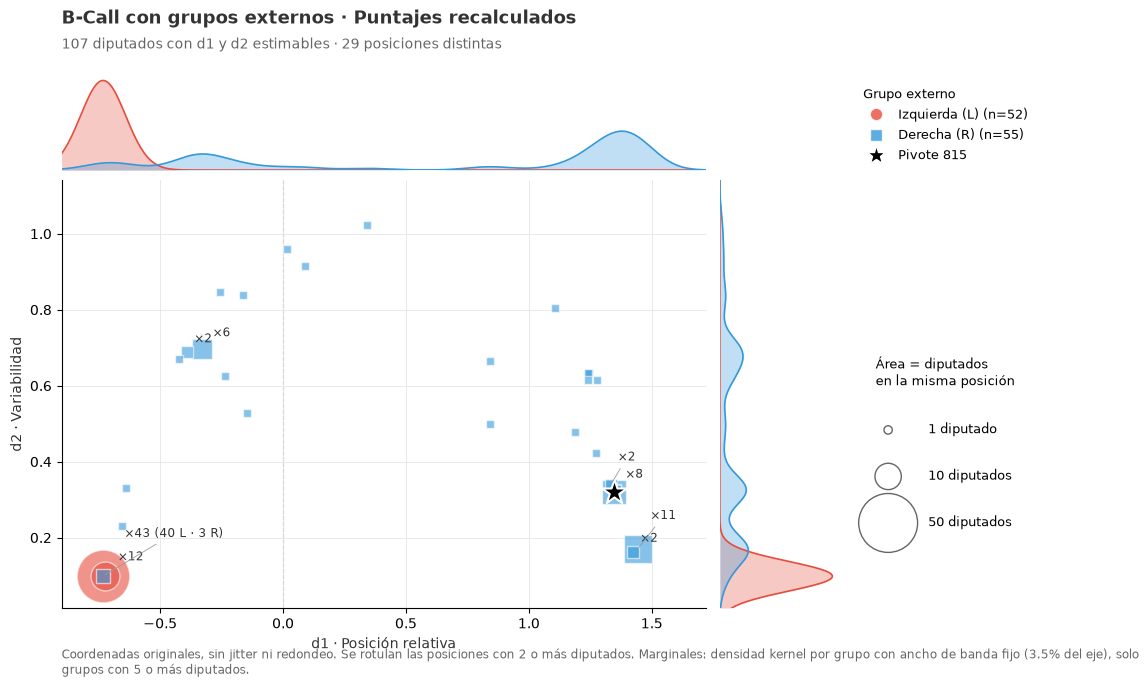

,d1_auto,d2_auto,m_i_auto,d1_externo,d2_externo,m_i_externo,diferencia_d1,diferencia_d2
diputado_id,,,,,,,,
74,-0.714709,0.089775,12,-0.725727,0.098143,12,-0.011019,0.008367
815,1.360165,0.320638,13,1.346576,0.320427,13,-0.013589,-0.000211
917,1.458364,0.163694,13,1.442475,0.169651,13,-0.015889,0.005957
948,-0.627907,0.324555,13,-0.637936,0.330189,13,-0.010029,0.005634
953,-0.317352,0.702703,13,-0.327883,0.695740,13,-0.010532,-0.006962
...,...,...,...,...,...,...,...,...
1174,1.360165,0.320638,13,1.346576,0.320427,13,-0.013589,-0.000211
1177,-0.714709,0.089775,12,-0.725727,0.098143,12,-0.011019,0.008367
1179,-0.726106,0.095272,13,-0.733835,0.098406,13,-0.007728,0.003134


,diferencia_d1,diferencia_d2
count,108.000000,107.000000
mean,-0.010481,0.001774
std,0.005170,0.005045
min,-0.016072,-0.010721
25%,-0.013589,-0.000211
50%,-0.010532,0.003134
75%,-0.007728,0.004853
max,0.031756,0.008516


In [55]:
fig_manual, ax_manual = graficar_plano_bcall(
    resultado_externo.diputados, 'cluster', pivote,
    titulo='B-Call con grupos externos · Puntajes recalculados',
    nombre_leyenda='Grupo externo',
    limites=(ax.get_xlim(), ax.get_ylim()),
)
plt.show()

comparacion_escenarios = resultado.diputados[['d1', 'd2', 'm_i']].join(
    resultado_externo.diputados[['d1', 'd2', 'm_i']],
    how='inner', lsuffix='_auto', rsuffix='_externo',
)
comparacion_escenarios['diferencia_d1'] = (
    comparacion_escenarios.d1_externo - comparacion_escenarios.d1_auto
)
comparacion_escenarios['diferencia_d2'] = (
    comparacion_escenarios.d2_externo - comparacion_escenarios.d2_auto
)
display(comparacion_escenarios)

# Ambas figuras usan escalas comunes para facilitar la comparación visual.
ax_manual.set_xlim(ax.get_xlim())
ax_manual.set_ylim(ax.get_ylim())
display(comparacion_escenarios[['diferencia_d1', 'diferencia_d2']].describe())


## 8. Análisis complementarios
Estos análisis ayudan a interpretar los resultados anteriores sin modificarlos. Responden cuatro preguntas: qué votaciones construyen el eje, qué patrón de voto hay detrás de cada posición, cómo se distribuyen las discrepancias con la clasificación externa y qué tan sensibles son los resultados a las decisiones de pivote, casos frontera y umbral.

El retiro de una votación por vez se calcula en `sensibilidad.py` (D03). Aquí solo se lee su resultado, sin recalcularlo.

In [ ]:
# Nombres, partidos y textos de votaciones, solo para presentar tablas.
votos_detalle = pd.read_csv(rutas['votos'], usecols=[
    'diputado_id', 'nombre', 'apellido_paterno', 'votacion_id', 'fecha', 'articulo',
    'tramite_constitucional',
])
fichas = votos_detalle.drop_duplicates('diputado_id').set_index('diputado_id')
nombres = (fichas.nombre + ' ' + fichas.apellido_paterno).rename('diputado')
# Partidos observados en el corpus, del más al menos frecuente.
partidos_diputado = afiliaciones.groupby('diputado_id').partido_alias.agg(
    lambda s: ' / '.join(s.value_counts().index)
).rename('partidos')
partido_principal = afiliaciones.groupby('diputado_id').partido_alias.agg(
    lambda s: s.value_counts().index[0]
).rename('partido_principal')


def resumir_texto(texto, largo=70):
    if pd.isna(texto):
        return 'Votación general'
    texto = ' '.join(str(texto).split())
    return texto if len(texto) <= largo else texto[:largo - 1] + '…'


info_votaciones = votos_detalle.drop_duplicates('votacion_id').set_index('votacion_id')
info_votaciones = pd.DataFrame({
    'fecha': info_votaciones.fecha.str[:10],
    'tramite': info_votaciones.tramite_constitucional,
    'materia': info_votaciones.articulo.map(resumir_texto),
})

### 8.1. Contribución de cada votación al eje
Para cada votación se muestran las medias de L y R en la codificación ternaria y la **separación** entre ambas (`|media_L − media_R|`, entre 0 y 2). Una separación alta indica que la votación distingue a los bloques. Las votaciones sin varianza no aportan a los puntajes.

El mapa de calor muestra el voto de cada diputado en la dirección del eje, con los diputados ordenados por d1. Rojo indica un voto en la dirección del bloque L y azul en la dirección del bloque R.

In [ ]:
contribucion = resultado.votaciones.join(info_votaciones)
contribucion['separacion_L_R'] = (contribucion.media_L - contribucion.media_R).abs()
contribucion['aporta_al_eje'] = (
    contribucion.incluida_por_varianza & contribucion.orientacion_definida
)
display(contribucion[[
    'fecha', 'tramite', 'materia', 'n_observados', 'media_L', 'media_R',
    'separacion_L_R', 'orientacion', 'aporta_al_eje',
]].sort_values(['aporta_al_eje', 'separacion_L_R'], ascending=False))

votaciones_eje = contribucion.loc[contribucion.aporta_al_eje].sort_values(
    ['fecha', 'votacion_id']
).index
print(f'Votaciones que aportan al eje: {len(votaciones_eje)} de {len(contribucion)}')

In [ ]:
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

# Voto en la dirección del eje: −1 = como el bloque L, +1 = como el bloque R.
orden_eje = resultado.diputados.sort_values(['d1', 'd2'], na_position='last').index
direccion = (
    matriz.loc[orden_eje, votaciones_eje]
    * resultado.votaciones.loc[votaciones_eje, 'orientacion']
)
mapa_colores = ListedColormap(
    [ESTILO_GRUPOS['L']['color'], '#D9D9D9', ESTILO_GRUPOS['R']['color']]
)
mapa_colores.set_bad('white')
fig_mapa, ax_mapa = plt.subplots(figsize=(10, 9))
ax_mapa.imshow(
    direccion.to_numpy(dtype=float), aspect='auto', interpolation='nearest',
    cmap=mapa_colores, norm=BoundaryNorm([-1.5, -0.5, 0.5, 1.5], 3),
)
ax_mapa.set_xticks(range(len(votaciones_eje)))
ax_mapa.set_xticklabels(
    [f"{v}\n{info_votaciones.loc[v, 'fecha']}" for v in votaciones_eje],
    rotation=90, fontsize=8,
)
ax_mapa.set_yticks([])
ax_mapa.set_ylabel('Diputados ordenados por d1 (menor arriba)')
grupos_ordenados = resultado.diputados.loc[orden_eje, 'grupo_bcall']
limite = int(grupos_ordenados.eq('L').sum())
ax_mapa.axhline(limite - 0.5, color='black', linewidth=1.2)
for nombre_grupo, y in [('L', limite / 2), ('R', limite + (len(orden_eje) - limite) / 2)]:
    ax_mapa.text(
        len(votaciones_eje) - 0.4, y,
        f"{etiquetas_grupos[nombre_grupo]}\nn={int(grupos_ordenados.eq(nombre_grupo).sum())}",
        va='center', ha='left', fontsize=9, color=TINTA,
    )
ax_mapa.legend(
    handles=[
        Patch(color=ESTILO_GRUPOS['L']['color'], label='Voto en la dirección de L'),
        Patch(color='#D9D9D9', label='Abstención'),
        Patch(color=ESTILO_GRUPOS['R']['color'], label='Voto en la dirección de R'),
        Patch(facecolor='white', edgecolor='#999999', label='Sin decisión registrada'),
    ],
    loc='upper left', bbox_to_anchor=(1.12, 1), frameon=False, fontsize=9,
)
ax_mapa.set_title('Votos orientados según el eje B-Call', loc='left', color=TINTA)
fig_mapa.tight_layout()
plt.show()

### 8.2. Perfiles de voto detrás de cada posición
d1 y d2 dependen solo del patrón de votos de cada diputado en las votaciones que aportan al eje, por lo que quienes votaron igual comparten coordenadas. Cada fila resume un patrón: **S** = Sí, **N** = No, **A** = Abstención, **·** = sin decisión, en el orden cronológico de la sección 8.1.

In [ ]:
codigos_voto = {1.0: 'S', -1.0: 'N', 0.0: 'A'}
patron_voto = matriz.loc[resultado.diputados.index, votaciones_eje].apply(
    lambda fila: ''.join(codigos_voto.get(v, '·') for v in fila), axis=1
).rename('patron')
por_diputado = (
    resultado.diputados[['d1', 'd2', 'm_i', 'grupo_bcall']]
    .join(patron_voto).join(partidos_diputado).join(nombres)
)
# Comprobación: un mismo patrón implica la misma coordenada.
assert por_diputado.dropna(subset=['d1']).groupby('patron').d1.agg(
    lambda s: s.max() - s.min()
).max() < 1e-9
perfiles = por_diputado.groupby('patron').agg(
    diputados=('d1', 'size'), d1=('d1', 'first'), d2=('d2', 'first'), m_i=('m_i', 'first'),
    grupo=('grupo_bcall', lambda s: '/'.join(sorted(set(s)))),
    partidos=('partidos', lambda s: ', '.join(f'{p} ({n})' for p, n in s.value_counts().items())),
).sort_values(['diputados', 'd1'], ascending=[False, True])
posiciones = resultado.diputados.dropna(subset=['d1', 'd2'])[['d1', 'd2']].drop_duplicates()
print(f'Patrones de voto distintos: {len(perfiles)} '
      f'({int(perfiles.d2.isna().sum())} sin d2 estimable) · '
      f'posiciones distintas en el plano d1/d2: {len(posiciones)}')
display(perfiles.head(15))

### 8.3. Discrepancias con la clasificación externa por partido
Se desglosa el cotejo de la sección 5 por partido vigente en cada votación. Una discrepancia indica que el diputado votó como el bloque contrario al de su partido en la clasificación externa; no es un error de estimación.

El gráfico muestra la distribución de d1 por partido, usando el partido más frecuente de cada diputado en el corpus. El área de cada marca es proporcional al número de diputados con el mismo valor.

In [ ]:
discrepancias_partido = comparables.assign(discrepa=~comparables.coincide).groupby(
    ['partido_nombre', 'grupo_externo']
).agg(
    filas_comparables=('discrepa', 'size'),
    filas_discrepantes=('discrepa', 'sum'),
    diputados=('diputado_id', 'nunique'),
    diputados_con_discrepancia=(
        'diputado_id', lambda s: s[~comparables.loc[s.index, 'coincide']].nunique()
    ),
).reset_index()
discrepancias_partido['proporcion_filas_discrepantes'] = (
    discrepancias_partido.filas_discrepantes / discrepancias_partido.filas_comparables
)
discrepancias_partido = discrepancias_partido.sort_values(
    ['filas_discrepantes', 'filas_comparables'], ascending=False
).reset_index(drop=True)
display(discrepancias_partido)

con_discrepancia = discrepancias_partido.loc[discrepancias_partido.filas_discrepantes.gt(0)]
for grupo_ext, filas in con_discrepancia.groupby('grupo_externo'):
    print(f'Grupo externo {grupo_ext}: {int(filas.diputados_con_discrepancia.sum())} diputados '
          f'con discrepancias en {len(filas)} partidos: '
          + ', '.join(f'{f.partido_nombre} ({f.diputados_con_discrepancia})'
                      for f in filas.itertuples()))

In [ ]:
d1_partido = resultado.diputados[['d1', 'grupo_bcall']].join(partido_principal).dropna(
    subset=['d1']
)
orden_partidos = d1_partido.groupby('partido_principal').d1.median().sort_values().index
marcas_partido = d1_partido.groupby(
    ['partido_principal', 'grupo_bcall', 'd1'], as_index=False
).size()
fig_partidos, ax_partidos = plt.subplots(figsize=(10, 0.42 * len(orden_partidos) + 1.6))
posicion_y = {partido: i for i, partido in enumerate(orden_partidos)}
for grupo_auto in ['L', 'R']:
    datos_grupo = marcas_partido.loc[marcas_partido.grupo_bcall.eq(grupo_auto)]
    estilo = ESTILO_GRUPOS[grupo_auto]
    ax_partidos.scatter(
        datos_grupo.d1, datos_grupo.partido_principal.map(posicion_y),
        s=AREA_POR_DIPUTADO * datos_grupo['size'], color=estilo['color'],
        marker=estilo['marker'], alpha=0.6, edgecolors='white', linewidths=1.0,
        label=f"{etiquetas_grupos[grupo_auto]} (n={int(datos_grupo['size'].sum())})",
    )
n_partido = d1_partido.partido_principal.value_counts()
ax_partidos.set_yticks(range(len(orden_partidos)))
ax_partidos.set_yticklabels([f'{p} (n={n_partido[p]})' for p in orden_partidos], fontsize=9)
ax_partidos.axvline(0, color='#999999', linewidth=0.8, linestyle='--')
ax_partidos.grid(True, axis='x', color='#E5E5E5', linewidth=0.6)
ax_partidos.spines[['top', 'right']].set_visible(False)
ax_partidos.set_xlim(ax.get_xlim())
ax_partidos.set_xlabel('d1 · Posición relativa B-Call')
ax_partidos.set_title('d1 por partido más frecuente del diputado', loc='left', color=TINTA)
ax_partidos.legend(title='Grupo B-Call', loc='upper left', bbox_to_anchor=(1.01, 1),
                   frameon=False, markerscale=0.5)
fig_partidos.tight_layout()
plt.show()

### 8.4. Sensibilidad a los casos frontera
Partido de la Gente y Partido Demócratas Chile se asignan a Derecha como casos frontera (decisión A03-025). Este escenario los deja sin clasificación externa y repite el cotejo y la estimación con grupos externos. El resultado automático no cambia, porque no usa la clasificación externa.

In [ ]:
import copy

casos_frontera = config['orientacion']['casos_frontera_derecha']
referencia_sin_frontera = copy.deepcopy(referencia)
for registro in referencia_sin_frontera['registros']:
    if registro['partido_nombre'] in casos_frontera:
        registro['codigo_binario'] = None
        registro['binaria_izq_der'] = 'Sin asignación'

universo_sin_frontera = asignar_grupos_externos(afiliaciones, referencia_sin_frontera)
grupos_sin_frontera = universo_sin_frontera.grupo_externo.dropna()
if grupos_sin_frontera.get(pivote) != 'R':
    raise ValueError('El pivote debe conservar el grupo R sin los casos frontera.')
resultado_sin_frontera = ModeloBCall().calcular(
    matriz=matriz, clustering=grupos_sin_frontera, pivot=pivote, threshold=threshold,
)
cotejo_sin_frontera = cotejar_asignacion(
    resultado.diputados.grupo_bcall, afiliaciones, referencia_sin_frontera
)
comparables_sin_frontera = cotejo_sin_frontera.loc[cotejo_sin_frontera.comparable]


def resumen_escenario(comparables_esc, grupos_esc, resultado_esc):
    return {
        'filas_comparables_cotejo': len(comparables_esc),
        'concordancia_por_fila': float(comparables_esc.coincide.mean()),
        'diputados_con_discrepancia': comparables_esc.loc[
            ~comparables_esc.coincide, 'diputado_id'
        ].nunique(),
        'diputados_con_grupo_externo': len(grupos_esc),
        'incluidos_escenario_externo': len(resultado_esc.diputados),
        'L_escenario_externo': int(resultado_esc.diputados.cluster.eq('L').sum()),
        'R_escenario_externo': int(resultado_esc.diputados.cluster.eq('R').sum()),
    }


comparacion_frontera = pd.DataFrame(dtype=object, data={
    'Con casos frontera': resumen_escenario(comparables, grupos_externos, resultado_externo),
    'Sin casos frontera': resumen_escenario(
        comparables_sin_frontera, grupos_sin_frontera, resultado_sin_frontera,
    ),
})
display(comparacion_frontera)

cambio_frontera = resultado_externo.diputados[['d1', 'd2']].join(
    resultado_sin_frontera.diputados[['d1', 'd2']], how='inner', rsuffix='_sin_frontera',
)
cambio_frontera['diferencia_d1'] = cambio_frontera.d1_sin_frontera - cambio_frontera.d1
print('Diputados comunes:', len(cambio_frontera),
      '| máx. |Δd1|:', round(float(cambio_frontera.diferencia_d1.abs().max()), 6),
      '| cambios de signo de d1:',
      int((np.sign(cambio_frontera.d1) != np.sign(cambio_frontera.d1_sin_frontera)).sum()))
salen = grupos_externos.index.difference(grupos_sin_frontera.index)
display(por_diputado.reindex(salen)[['diputado', 'partidos', 'grupo_bcall', 'd1']]
        .rename_axis('diputado_id').assign(grupo_externo_base=grupos_externos.reindex(salen)))

### 8.5. Robustez del pivote
El agrupamiento automático parte de los dos diputados más distantes entre sí y no depende del pivote. El pivote solo decide qué grupo es R. Se recalcula el modelo con cada pivote elegible según el mismo criterio de la sección 2: UDI o Partido Republicano, afiliación consistente y participación mayor que el umbral. Si todos quedan en el mismo grupo, la orientación del eje no depende de cuál se elija.

In [ ]:
partidos_pivote = ('Unión Demócrata Independiente', 'Partido Republicano')
afiliacion_unica = afiliaciones.groupby('diputado_id').partido_nombre.agg(
    lambda s: s.iloc[0] if s.nunique() == 1 else None
)
participacion = matriz.notna().sum(axis=1) / matriz.shape[1]
candidatos_pivote = afiliacion_unica.index[
    afiliacion_unica.isin(partidos_pivote)
    & participacion.reindex(afiliacion_unica.index).gt(threshold)
]
filas_pivote = []
for candidato in candidatos_pivote:
    alternativo = ModeloBCall().calcular_auto(
        matriz, pivot=candidato, distance_method=metodo_distancia, threshold=threshold,
    )
    diferencia = (alternativo.diputados.d1 - resultado.diputados.d1).abs()
    filas_pivote.append({
        'diputado_id': candidato, 'diputado': nombres.get(candidato),
        'partido': afiliacion_unica[candidato],
        'participacion': participacion[candidato],
        'grupo_automatico': resultado.clustering_auto[candidato],
        'mismos_grupos': alternativo.diputados.grupo_bcall.equals(resultado.diputados.grupo_bcall),
        'max_abs_diferencia_d1': float(diferencia.max()),
    })
robustez_pivote = pd.DataFrame(filas_pivote).set_index('diputado_id')
display(robustez_pivote.sort_values(['participacion', 'diputado_id'],
                                    ascending=[False, True]))
print(f'Pivotes elegibles: {len(robustez_pivote)} · en el mismo grupo que {pivote}: '
      f"{int(robustez_pivote.grupo_automatico.eq(resultado.clustering_auto[pivote]).sum())} · "
      f'mismo eje (|Δd1| < 1e-9): '
      f'{int(robustez_pivote.max_abs_diferencia_d1.lt(1e-9).sum())}')

### 8.6. Alcance del umbral de participación
El filtro exige participación estrictamente mayor que `threshold` sobre todas las votaciones de la matriz. Se traduce ese umbral a un número mínimo de decisiones, se listan los excluidos y se resume la influencia de cada votación según el retiro de una votación por vez (D03), leído desde `sensibilidad.csv`.

Para medir esa influencia se usan las diferencias de d1 y no la columna `cambio_orden`, que considera cambios de orden diferencias de punto flotante entre diputados empatados.

In [ ]:
n_votaciones = matriz.shape[1]
minimo_decisiones = int(np.floor(threshold * n_votaciones)) + 1
print(f'Con {n_votaciones} votaciones, participación > {threshold:.0%} exige al menos '
      f'{minimo_decisiones} decisiones sustantivas.')

excluidos_umbral = resultado.seleccion.loc[~resultado.seleccion.incluido].join(nombres)
excluidos_umbral = excluidos_umbral.join(partidos_diputado)
excluidos_umbral['n_decisiones'] = matriz.loc[excluidos_umbral.index].notna().sum(axis=1)
excluidos_umbral['votaciones_con_decision'] = [
    matriz.columns[matriz.loc[i].notna()].tolist() for i in excluidos_umbral.index
]
display(excluidos_umbral[['diputado', 'partidos', 'n_decisiones', 'participacion',
                          'votaciones_con_decision', 'razon_exclusion']])
print('Votaciones en que participaron los excluidos:',
      pd.Series([v for lista in excluidos_umbral.votaciones_con_decision for v in lista])
      .value_counts().to_dict())

ruta_sensibilidad = raiz / 'F4/data/reports/sensibilidad.csv'
influencia_votaciones = None
if ruta_sensibilidad.is_file() and ruta_sensibilidad.stat().st_size > 0:
    sensibilidad = pd.read_csv(ruta_sensibilidad)
    sens_d1 = sensibilidad.loc[
        sensibilidad.metodo.eq('bcall_d1')
        & sensibilidad.umbral_cobertura.eq(sensibilidad.umbral_cobertura.min())
    ]
    sens_d1 = sens_d1.assign(votacion_retirada=sens_d1.votacion_retirada.astype('int64'))
    influencia_votaciones = sens_d1.groupby('votacion_retirada').agg(
        diputados=('id', 'nunique'),
        max_abs_diferencia_d1=('diferencia_abs', 'max'),
        mediana_abs_diferencia_d1=('diferencia_abs', 'median'),
        cambios_signo_d1=('cambio_signo', lambda s: int(s.eq(True).sum())),
    ).join(info_votaciones).sort_values('max_abs_diferencia_d1', ascending=False)
    display(influencia_votaciones)
else:
    print('No existe sensibilidad.csv; ejecuta primero sensibilidad.py (D03).')

### 8.7. d1 automático frente a d1 con grupos externos
Se comparan los puntajes de los diputados presentes en ambos escenarios. La diagonal indica igualdad. El color corresponde al grupo externo y el área, al número de diputados con el mismo par de valores.

In [ ]:
pares_d1 = comparacion_escenarios[['d1_auto', 'd1_externo']].dropna().join(
    resultado_externo.diputados.cluster
)
marcas_pares = pares_d1.groupby(['cluster', 'd1_auto', 'd1_externo'], as_index=False).size()
fig_comparacion, ax_comparacion = plt.subplots(figsize=(7.5, 7))
for grupo_ext in ['L', 'R']:
    datos_grupo = marcas_pares.loc[marcas_pares.cluster.eq(grupo_ext)]
    estilo = ESTILO_GRUPOS[grupo_ext]
    ax_comparacion.scatter(
        datos_grupo.d1_auto, datos_grupo.d1_externo,
        s=AREA_POR_DIPUTADO * datos_grupo['size'], color=estilo['color'],
        marker=estilo['marker'], alpha=0.6, edgecolors='white', linewidths=1.0,
        label=f"{etiquetas_grupos[grupo_ext]} externo (n={int(datos_grupo['size'].sum())})",
    )
valores_d1 = pares_d1[['d1_auto', 'd1_externo']]
extremos = [min(ax.get_xlim()[0], valores_d1.min().min()),
            max(ax.get_xlim()[1], valores_d1.max().max())]
ax_comparacion.plot(extremos, extremos, color='#999999', linewidth=0.8, linestyle='--',
                    label='Igualdad')
ax_comparacion.set_xlim(extremos)
ax_comparacion.set_ylim(extremos)
ax_comparacion.set_aspect('equal')
ax_comparacion.grid(True, color='#E5E5E5', linewidth=0.6)
ax_comparacion.spines[['top', 'right']].set_visible(False)
ax_comparacion.set(xlabel='d1 · B-Call automático', ylabel='d1 · B-Call con grupos externos')
ax_comparacion.set_title('d1 en ambos escenarios', loc='left', color=TINTA)
ax_comparacion.legend(loc='upper left', frameon=False, markerscale=0.5, fontsize=9)
fig_comparacion.tight_layout()
plt.show()
print(f'Diputados comunes: {len(pares_d1)} · '
      f"Pearson: {pares_d1.d1_auto.corr(pares_d1.d1_externo):.4f} · "
      f'Spearman: {pares_d1.d1_auto.rank().corr(pares_d1.d1_externo.rank()):.4f} · '
      f'máx. |Δd1|: {(pares_d1.d1_externo - pares_d1.d1_auto).abs().max():.4f}')

### 8.8. Posiciones intermedias y alta variabilidad
Se identifican dos situaciones que conviene revisar caso a caso:

- **d1 con signo opuesto a su grupo:** diputados que el agrupamiento ubica en un bloque, pero cuyo voto promedio queda del otro lado del eje.
- **Alta variabilidad:** d2 en el cuartil superior. Corresponde a diputados que no votaron de forma consistente con un mismo lado del eje.

In [ ]:
columnas_revision = ['diputado', 'partidos', 'grupo_bcall', 'd1', 'd2', 'm_i', 'patron']
signo_opuesto = por_diputado.loc[
    (por_diputado.grupo_bcall.eq('L') & por_diputado.d1.gt(0))
    | (por_diputado.grupo_bcall.eq('R') & por_diputado.d1.lt(0))
]
corte_d2 = por_diputado.d2.quantile(0.75)
alta_variabilidad = por_diputado.loc[por_diputado.d2.ge(corte_d2)].sort_values(
    'd2', ascending=False
)
print(f'd1 con signo opuesto a su grupo: {len(signo_opuesto)} diputados')
display(signo_opuesto[columnas_revision].sort_values('d1'))
print(f'd2 en el cuartil superior (d2 ≥ {corte_d2:.3f}): {len(alta_variabilidad)} diputados')
display(alta_variabilidad[columnas_revision])
posiciones_revision = pd.concat([
    signo_opuesto.assign(criterio='d1_signo_opuesto_al_grupo'),
    alta_variabilidad.assign(criterio='d2_cuartil_superior'),
])[['criterio', *columnas_revision]]

## 9. Exportación y reproducibilidad
Las salidas se almacenan en `F4/data/results/bcall`: resultados individuales, diagnósticos de votaciones, selección de diputados, votos orientados, universo externo, cotejo histórico, comparación de escenarios, análisis complementarios de la sección 8 y gráficos.

El registro de ejecución conserva fecha UTC, versión del código cuando está disponible, hashes SHA-256 de las entradas, parámetros, clasificación binaria aplicada, versiones del entorno y conteos. Las listas y los diccionarios de diagnóstico se serializan como JSON dentro de los CSV. La ejecución reemplaza las salidas correspondientes a este análisis.


In [ ]:
salida = raiz / 'F4/data/results/bcall'
salida.mkdir(parents=True, exist_ok=True)
tablas = {
    'diputados': resultado.diputados,
    'diputados_externo': resultado_externo.diputados,
    'votaciones_externo': resultado_externo.votaciones,
    'seleccion_externo': resultado_externo.seleccion,
    'votos_orientados_externo': resultado_externo.votos_orientados,
    'universo_externo': universo_externo,
    'comparacion_auto_externo': comparacion_escenarios,
    'votaciones': resultado.votaciones,
    'seleccion': resultado.seleccion,
    'votos_orientados': resultado.votos_orientados,
    'contribucion_votaciones': contribucion,
    'perfiles_voto': perfiles,
    'discrepancias_partido': discrepancias_partido,
    'escenario_sin_casos_frontera': comparacion_frontera,
    'cambio_d1_sin_casos_frontera': cambio_frontera,
    'robustez_pivote': robustez_pivote,
    'excluidos_umbral': excluidos_umbral,
    'posiciones_revision': posiciones_revision,
}
if influencia_votaciones is not None:
    tablas['influencia_votaciones'] = influencia_votaciones
for nombre, tabla in tablas.items():
    exportable = tabla.drop(columns=['estado'], errors='ignore').copy()
    for columna in exportable.columns:
        exportable[columna] = exportable[columna].map(
            lambda v: json.dumps(v, ensure_ascii=False, default=int)
            if isinstance(v, (list, dict)) else v
        )
    exportable.to_csv(salida / f'{nombre}.csv', encoding='utf-8')
cotejo.to_csv(salida / 'cotejo_asignacion.csv', index=False, encoding='utf-8')
resultado.clustering_auto.to_csv(salida / 'clustering_auto.csv', encoding='utf-8')
fig.savefig(salida / 'posicion_variabilidad.png', dpi=180, bbox_inches='tight')
fig_externo.savefig(salida / 'posicion_variabilidad_grupo_externo.png', dpi=180, bbox_inches='tight')
fig_manual.savefig(salida / 'posicion_variabilidad_bcall_manual.png', dpi=180, bbox_inches='tight')
fig_mapa.savefig(salida / 'mapa_votos_orientados.png', dpi=180, bbox_inches='tight')
fig_partidos.savefig(salida / 'd1_por_partido.png', dpi=180, bbox_inches='tight')
fig_comparacion.savefig(salida / 'd1_auto_vs_externo.png', dpi=180, bbox_inches='tight')
git = subprocess.run(['git', '-C', str(raiz), 'rev-parse', 'HEAD'], capture_output=True, text=True)
registro = {
    'fecha_utc': datetime.now(timezone.utc).isoformat(),
    'commit_local': git.stdout.strip() if git.returncode == 0 else None,
    'tipo_analisis': 'descriptivo',
    'pivot': int(pivote), 'threshold': threshold, 'distance_method': metodo_distancia,
    'referencia_bcall': config['bcall']['commit_referencia'],
    'entradas': {nombre: {'ruta': str(ruta.relative_to(raiz)),
                         'sha256': hashlib.sha256(ruta.read_bytes()).hexdigest()}
                 for nombre, ruta in rutas.items()},
    'entorno': {'python': platform.python_version(), 'pandas': pd.__version__, 'numpy': np.__version__},
    'conteos': {clave: int(valor) for clave, valor in perfil.items()},
    'incluidos': len(resultado.diputados),
    'escenario_externo': {
        'regla': 'etiqueta_unica_de_partidos_observados_ignorar_independientes',
        'clasificacion_binaria': 'codigo_binario_de_la_referencia_sin_modificar',
        'grupos_proporcionados_por': 'JSON_ideologico_y_afiliacion_historica',
        'argumento_modelo': 'clustering',
        'puntajes_recalculados': True,
        'independientes': 'asignar_desde_partido_si_existe_solo_independiente_sin_grupo',
        'asignados_desde_partido_con_registros_independiente': int(universo_externo.asignacion_desde_partido_con_registros_independiente.sum()),
        'incluidos': len(resultado_externo.diputados),
        'excluidos': int((~resultado_externo.seleccion.incluido).sum()),
        'diputados_comunes_comparacion': len(comparacion_escenarios),
    },
    'excluidos': int((~resultado.seleccion.incluido).sum()),
    'filas_comparables_cotejo': len(comparables),
    'concordancia_por_fila': concordancia,
    'analisis_complementarios': {
        'votaciones_que_aportan_al_eje': len(votaciones_eje),
        'patrones_de_voto': len(perfiles),
        'minimo_decisiones_por_umbral': minimo_decisiones,
        'pivotes_elegibles': len(robustez_pivote),
        'pivotes_con_mismo_eje': int(
            robustez_pivote.max_abs_diferencia_d1.lt(1e-9).sum()
        ),
        'escenario_sin_casos_frontera': {
            'casos_frontera': casos_frontera,
            'concordancia_por_fila': comparacion_frontera.loc[
                'concordancia_por_fila', 'Sin casos frontera'],
            'incluidos_escenario_externo': int(comparacion_frontera.loc[
                'incluidos_escenario_externo', 'Sin casos frontera']),
        },
    },
}
(salida / 'ejecucion_bcall.json').write_text(
    json.dumps(registro, ensure_ascii=False, indent=2), encoding='utf-8'
)
print('Resultados guardados en:', salida)


## 10. Interpretación y alcance
B-Call caracteriza el comportamiento relativo de los diputados en las votaciones del corpus. El automático estima grupos desde los votos; el contraste gráfico conserva esos puntajes; el escenario externo calcula puntajes con grupos partidarios definidos metodológicamente.

La concordancia histórica se mide por fila diputado × votación, no por diputado. La participación observada no equivale a asistencia. Las exclusiones externas modifican la población de referencia y la estandarización. Los puntajes no deben extrapolarse a una clasificación ideológica global de cada diputado.

### Referencias metodológicas
- [Paquete B-Call](https://github.com/bcallr/bcall).
- [Ejemplo de análisis automático y con grupos externos](https://alcatruz.github.io/bcall-example/).

La implementación de este proyecto utiliza el módulo Python `ModeloBCall` y conserva diagnósticos para evaluar cobertura, orientación y estimabilidad.


## 11. Síntesis de resultados
La tabla siguiente resume los universos analizados y su composición. El diagnóstico de exclusiones permite distinguir ausencia de clasificación externa y participación insuficiente. Los conteos se obtienen directamente de los resultados de la ejecución.


In [57]:
sintesis = pd.DataFrame({
    'Automático': {
        'Diputados incluidos': len(resultado.diputados),
        'Diputados excluidos': int((~resultado.seleccion.incluido).sum()),
        'Izquierda (L)': int(resultado.diputados.grupo_bcall.eq('L').sum()),
        'Derecha (R)': int(resultado.diputados.grupo_bcall.eq('R').sum()),
    },
    'Grupos externos': {
        'Diputados incluidos': len(resultado_externo.diputados),
        'Diputados excluidos': int((~resultado_externo.seleccion.incluido).sum()),
        'Izquierda (L)': int(resultado_externo.diputados.cluster.eq('L').sum()),
        'Derecha (R)': int(resultado_externo.diputados.cluster.eq('R').sum()),
    },
})
display(sintesis)
display(universo_externo.groupby(
    ['razon_sin_grupo_externo', 'seleccion_razon_exclusion'], dropna=False
).size().rename('Diputados').to_frame())
display(pd.Series({
    'Filas comparables del cotejo histórico': len(comparables),
    'Filas con discrepancia': int((~comparables.coincide).sum()),
    'Diputados con alguna discrepancia': comparables.loc[
        ~comparables.coincide, 'diputado_id'
    ].nunique(),
    'Concordancia por fila': concordancia,
    'Diputados comunes a ambos escenarios': len(comparacion_escenarios),
}).to_frame('Valor'))


,Automático,Grupos externos
Diputados incluidos,136,108
Diputados excluidos,15,43
Izquierda (L),94,53
Derecha (R),42,55


Diputados
razon_sin_grupo_externo   seleccion_razon_exclusion                
SIN_CLASIFICACION_EXTERNA SIN_CLUSTER                            32
NaN                       PARTICIPACION_NO_SUPERA_UMBRAL         11
                          NaN                                   108

,Valor
Filas comparables del cotejo histórico,1479.00000
Filas con discrepancia,256.00000
Diputados con alguna discrepancia,21.00000
Concordancia por fila,0.82691
Diputados comunes a ambos escenarios,108.00000
